# 01 - Análisis Exploratorio de Datos (EDA)

**Proyecto**: GoalPredict 2026 — Plataforma de Predicción Deportiva con ML aplicada al Mundial FIFA 2026

**Dataset principal**: Fjelstul World Cup Database (1930-2018, 21 mundiales, 900 partidos).

**Objetivo del notebook**: entender la forma, distribuciones, calidad y limitaciones del dataset antes de pasar a feature engineering y modelado. Contestar:

1. ¿Cuál es la distribución de resultados (W/D/L)? — define la línea base del clasificador.
2. ¿Hay ventaja de localía / partidos en sede neutral?
3. ¿Cómo se distribuyen los goles por partido (total, 1T, 2T)?
4. ¿Cuál es la distribución de tarjetas por partido?
5. ¿Qué equipos tienen más historial (más muestras de entrenamiento)?
6. ¿Qué features podemos construir y cuáles requieren datasets adicionales?

## Setup

In [3]:
import sys
from pathlib import Path

# Agregar ml/ al path para poder importar src.data
ROOT = Path.cwd().parents[0]  # ml/
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import FjelstulLoader

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 60)

data = FjelstulLoader.load_all()
print("Datasets cargados:")
for name in ["matches", "team_appearances", "goals", "bookings", "teams", "tournaments"]:
    print(f"  {name:20s} {getattr(data, name).shape}")

Datasets cargados:
  matches              (900, 37)
  team_appearances     (1800, 36)
  goals                (2548, 27)
  bookings             (2466, 26)
  teams                (84, 11)
  tournaments          (21, 18)


## 1. Distribución de resultados (variable objetivo del clasificador)

El modelo de la **capa gratuita** predice tres clases: victoria local, empate, victoria visitante. Veamos qué tan balanceadas están en el dataset histórico.

In [4]:
matches = data.matches.copy()
result_counts = matches["result"].value_counts()
print(result_counts)
print(f"\nProporción:")
print((result_counts / len(matches) * 100).round(2).astype(str) + " %")

result
home team win    513
away team win    218
draw             169
Name: count, dtype: int64

Proporción:
result
home team win     57.0 %
away team win    24.22 %
draw             18.78 %
Name: count, dtype: str


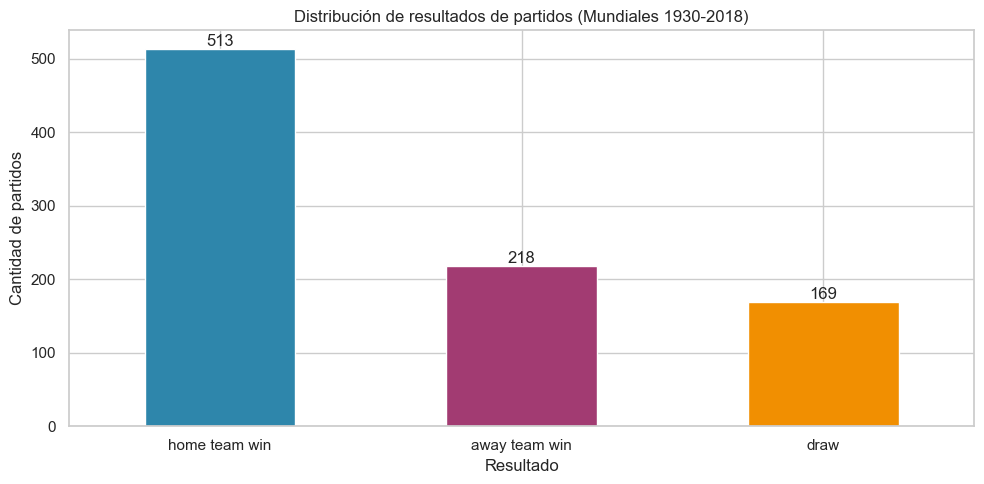

In [5]:
fig, ax = plt.subplots()
result_counts.plot(kind="bar", ax=ax, color=["#2E86AB", "#A23B72", "#F18F01"])
ax.set_title("Distribución de resultados de partidos (Mundiales 1930-2018)")
ax.set_xlabel("Resultado")
ax.set_ylabel("Cantidad de partidos")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
plt.tight_layout(); plt.show()

> **Hallazgo esperado**: las clases son desbalanceadas (más victorias locales que empates). Tendremos que considerar `class_weight="balanced"` o sobremuestreo (SMOTE) cuando entrenemos el modelo.

**Baseline a vencer**: predecir siempre la clase mayoritaria. Accuracy = proporción de la clase mayoritaria.

## 2. ¿Hay ventaja de localía en el Mundial?

En Mundiales muchas veces el "home team" es solo un nombre administrativo (la mayoría se juegan en cancha neutral). Veamos:

In [6]:
# Unir matches con host country del torneo para identificar partidos en sede del local
matches_with_host = matches.merge(
    data.tournaments[["tournament_id", "host_country"]], on="tournament_id", how="left"
)
matches_with_host["home_is_host"] = matches_with_host["home_team_name"] == matches_with_host["host_country"]
print("Partidos donde el 'home team' es el país anfitrión:", matches_with_host["home_is_host"].sum())
print("Total de partidos:", len(matches_with_host))

Partidos donde el 'home team' es el país anfitrión: 80
Total de partidos: 900


In [7]:
# Tasa de victoria del 'home team' según si juega en su país o no
win_rate = matches_with_host.groupby("home_is_host")["home_team_win"].agg(["mean", "count"])
win_rate.columns = ["win_rate_home", "n_matches"]
print(win_rate)

              win_rate_home  n_matches
home_is_host                          
False              0.552439        820
True               0.750000         80


## 3. Distribución de goles por partido

Esto alimenta el modelo de regresión de **goles totales** y el de **Over/Under 2.5** de la capa premium.

In [8]:
matches["total_goals"] = matches["home_team_score"] + matches["away_team_score"]
print("Goles por partido — estadísticas:")
print(matches["total_goals"].describe().round(2))
print(f"\nP(Over 2.5 goles): {(matches['total_goals'] > 2.5).mean():.2%}")

Goles por partido — estadísticas:
count    900.00
mean       2.83
std        1.93
min        0.00
25%        1.00
50%        3.00
75%        4.00
max       12.00
Name: total_goals, dtype: float64

P(Over 2.5 goles): 52.33%


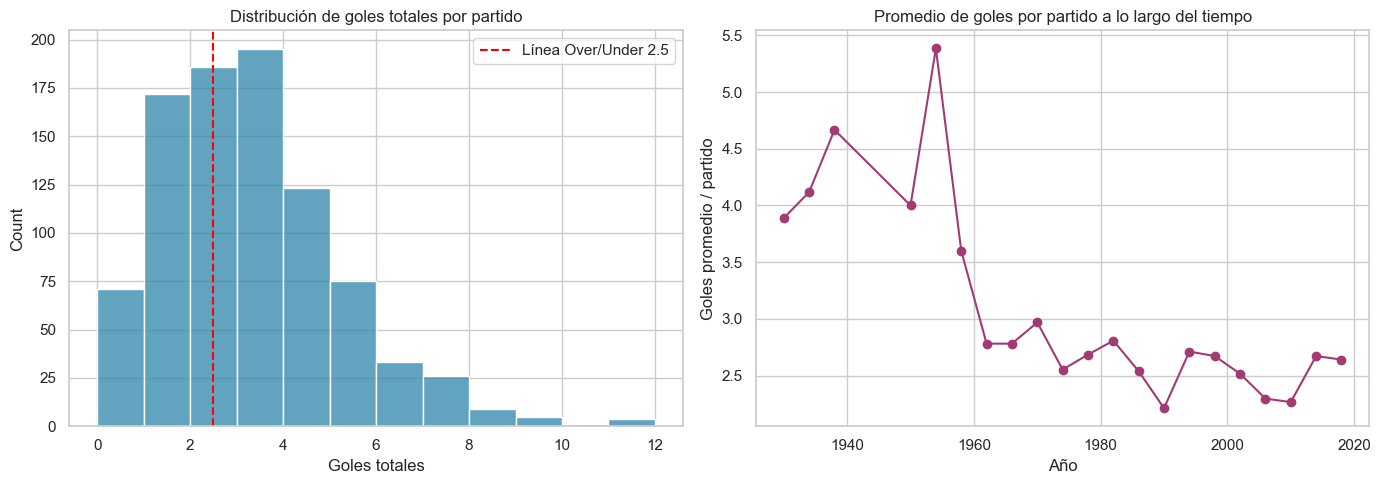

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(matches["total_goals"], bins=range(0, 13), ax=axes[0], color="#2E86AB")
axes[0].axvline(2.5, color="red", linestyle="--", label="Línea Over/Under 2.5")
axes[0].set_title("Distribución de goles totales por partido")
axes[0].set_xlabel("Goles totales"); axes[0].legend()

# Evolución temporal del promedio de goles por mundial
matches_per_tournament = (
    matches.groupby("tournament_id")["total_goals"].mean()
    .reset_index().merge(data.tournaments[["tournament_id", "year"]], on="tournament_id")
    .sort_values("year")
)
axes[1].plot(matches_per_tournament["year"], matches_per_tournament["total_goals"], marker="o", color="#A23B72")
axes[1].set_title("Promedio de goles por partido a lo largo del tiempo")
axes[1].set_xlabel("Año"); axes[1].set_ylabel("Goles promedio / partido")
plt.tight_layout(); plt.show()

### 3.1 Goles por tiempo (primer vs segundo tiempo)

Variable objetivo de los modelos de regresión **"goles en 1T"** y **"goles en 2T"** de la capa premium.

Promedio de goles por partido:
period
first_half     1.340
second_half    1.733
extra_time     0.000
dtype: float64


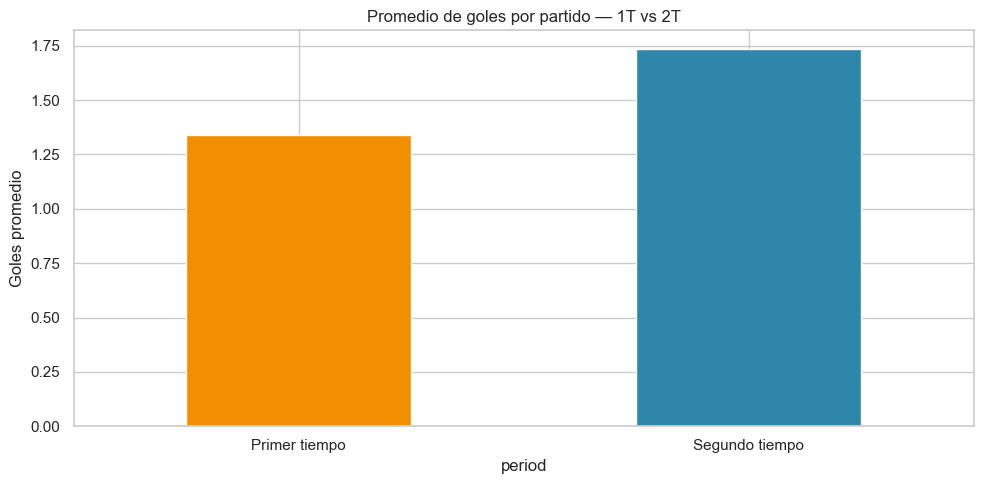

In [10]:
goals = data.goals.copy()

# Clasificar el periodo en una variable binaria simple
def classify_period(period: str) -> str:
    if pd.isna(period):
        return "unknown"
    if "first half" in period:
        return "first_half"
    if "second half" in period:
        return "second_half"
    if "extra time" in period:
        return "extra_time"
    return "other"

goals["period"] = goals["match_period"].apply(classify_period)

# Goles por partido por periodo
goals_per_match_period = (
    goals.groupby(["match_id", "period"]).size().unstack(fill_value=0)
    .reindex(columns=["first_half", "second_half", "extra_time"], fill_value=0)
)
print("Promedio de goles por partido:")
print(goals_per_match_period.mean().round(3))

fig, ax = plt.subplots()
goals_per_match_period[["first_half", "second_half"]].mean().plot(kind="bar", ax=ax, color=["#F18F01", "#2E86AB"])
ax.set_title("Promedio de goles por partido — 1T vs 2T")
ax.set_ylabel("Goles promedio"); ax.set_xticklabels(["Primer tiempo", "Segundo tiempo"], rotation=0)
plt.tight_layout(); plt.show()

## 4. Tarjetas por partido

Variable objetivo del modelo de regresión de **tarjetas** de la capa premium.

In [11]:
bookings = data.bookings.copy()

cards_per_match = bookings.groupby("match_id").agg(
    yellow=("yellow_card", "sum"),
    red=("red_card", "sum"),
    second_yellow=("second_yellow_card", "sum"),
).reset_index()

# Partidos sin tarjetas no aparecen en bookings, agregarlos como 0
cards_per_match = matches[["match_id"]].merge(cards_per_match, on="match_id", how="left").fillna(0)

print(cards_per_match[["yellow", "red", "second_yellow"]].describe().round(2))

       yellow     red  second_yellow
count  900.00  900.00         900.00
mean     2.64    0.10           0.07
std      2.46    0.34           0.30
min      0.00    0.00           0.00
25%      0.00    0.00           0.00
50%      2.00    0.00           0.00
75%      4.00    0.00           0.00
max     16.00    3.00           4.00


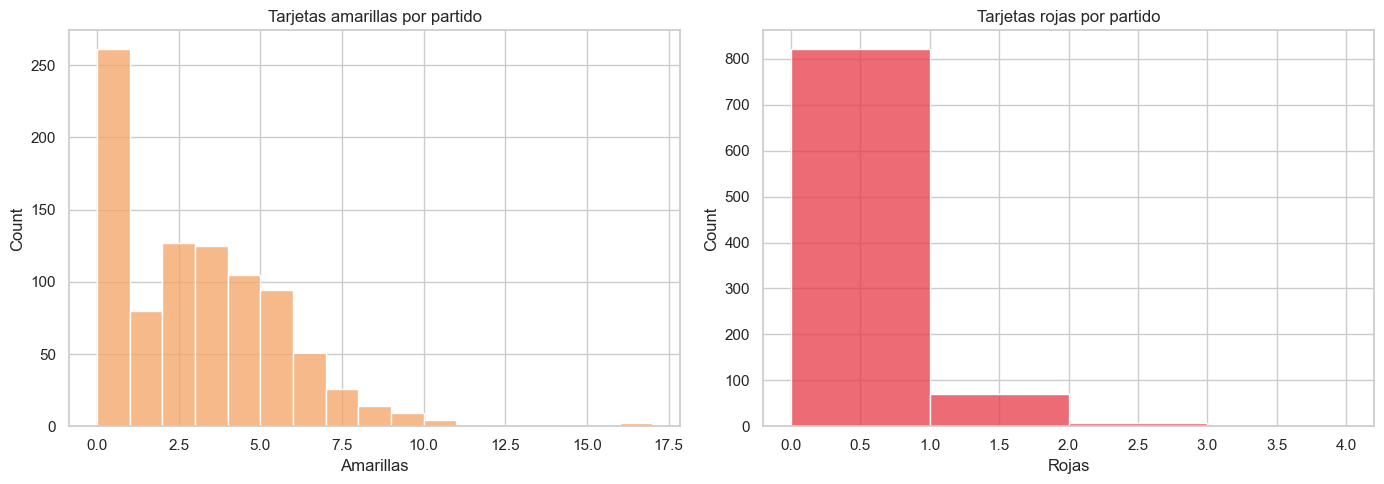

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(cards_per_match["yellow"], bins=range(0, int(cards_per_match["yellow"].max()) + 2), ax=axes[0], color="#F4A261")
axes[0].set_title("Tarjetas amarillas por partido")
axes[0].set_xlabel("Amarillas")

sns.histplot(cards_per_match["red"], bins=range(0, int(cards_per_match["red"].max()) + 2), ax=axes[1], color="#E63946")
axes[1].set_title("Tarjetas rojas por partido")
axes[1].set_xlabel("Rojas")
plt.tight_layout(); plt.show()

> **Hallazgo importante**: las tarjetas amarillas tienen suficiente varianza para entrenar regresión. Las rojas son raras (la mediana es 0) — para predecirlas podríamos plantearlo como **clasificación binaria** (¿hay roja? sí/no) o **regresión de Poisson** en vez de RF Regressor estándar.

## 5. Equipos con más historial

Los equipos con más participaciones tienen más muestras de entrenamiento. Útil para entender qué predicciones serán más confiables vs más experimentales.

In [13]:
team_apps = data.team_appearances.copy()

team_stats = team_apps.groupby("team_name").agg(
    n_matches=("match_id", "count"),
    wins=("win", "sum"),
    draws=("draw", "sum"),
    losses=("lose", "sum"),
    goals_for=("goals_for", "sum"),
    goals_against=("goals_against", "sum"),
).assign(
    win_rate=lambda d: (d["wins"] / d["n_matches"]).round(3),
    avg_goals_for=lambda d: (d["goals_for"] / d["n_matches"]).round(2),
    avg_goals_against=lambda d: (d["goals_against"] / d["n_matches"]).round(2),
).sort_values("n_matches", ascending=False)

team_stats.head(15)

,n_matches,wins,draws,losses,goals_for,goals_against,win_rate,avg_goals_for,avg_goals_against
team_name,,,,,,,,,
Brazil,109,76,14,19,229,105,0.697,2.10,0.96
Italy,83,46,17,20,128,77,0.554,1.54,0.93
Argentina,81,47,10,24,137,93,0.580,1.69,1.15
England,69,30,17,22,91,64,0.435,1.32,0.93
France,66,36,9,21,120,77,0.545,1.82,1.17
Spain,63,31,11,21,99,72,0.492,1.57,1.14
West Germany,62,39,11,12,131,77,0.629,2.11,1.24
Mexico,57,16,12,29,60,98,0.281,1.05,1.72
Uruguay,56,25,11,20,87,74,0.446,1.55,1.32


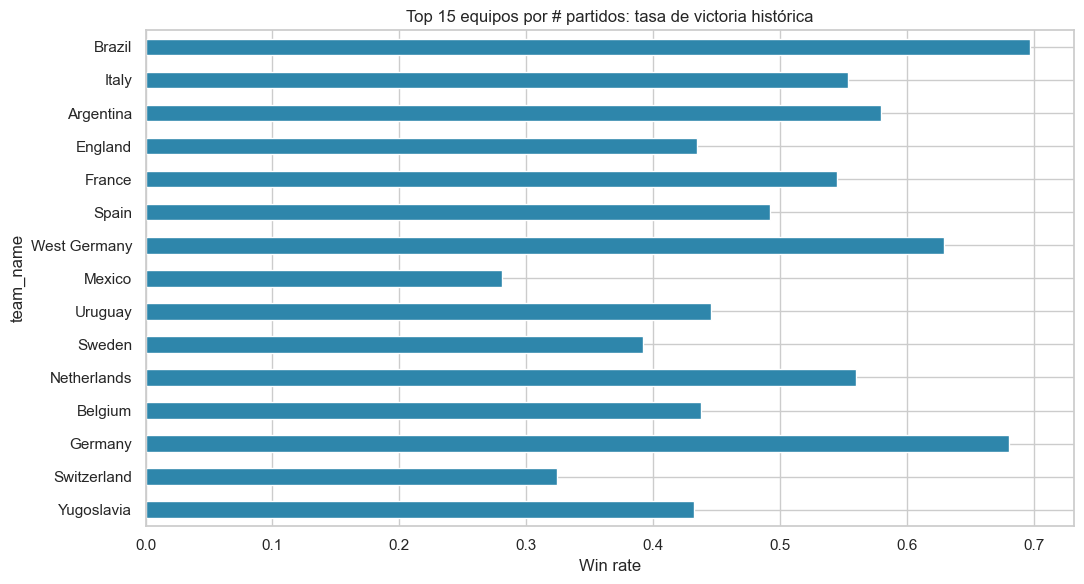

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
top15 = team_stats.head(15)
top15["win_rate"].plot(kind="barh", ax=ax, color="#2E86AB")
ax.set_title("Top 15 equipos por # partidos: tasa de victoria histórica")
ax.set_xlabel("Win rate"); ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 6. Calidad de datos: nulos, duplicados, outliers

In [15]:
print("--- Nulos en matches ---")
nulls = matches.isnull().sum()
print(nulls[nulls > 0] if (nulls > 0).any() else "Sin nulos")

print("\n--- Duplicados ---")
print(f"matches.match_id duplicados: {matches['match_id'].duplicated().sum()}")
print(f"team_appearances duplicados: {team_apps.duplicated().sum()}")

print("\n--- Outliers en goles ---")
print(matches[["home_team_score", "away_team_score", "total_goals"]].describe())
print(f"\nPartido con más goles: {matches.loc[matches['total_goals'].idxmax(), 'match_name']} "
      f"({matches['total_goals'].max()} goles)")

--- Nulos en matches ---
Sin nulos

--- Duplicados ---
matches.match_id duplicados: 0
team_appearances duplicados: 0

--- Outliers en goles ---
       home_team_score  away_team_score  total_goals
count       900.000000       900.000000   900.000000
mean          1.780000         1.051111     2.831111
std           1.604513         1.073313     1.930474
min           0.000000         0.000000     0.000000
25%           1.000000         0.000000     1.000000
50%           1.000000         1.000000     3.000000
75%           3.000000         2.000000     4.000000
max          10.000000         7.000000    12.000000

Partido con más goles: Austria v Switzerland (12 goles)


## 7. Limitaciones del dataset Fjelstul y qué features faltan

Comparando contra las features solicitadas en la propuesta:

| Feature requerida | ¿Disponible en Fjelstul? | Acción |
|---|---|---|
| Resultado W/D/L | ✅ `matches.result` | OK |
| Goles a favor / en contra | ✅ `team_appearances` | OK |
| Goles 1T / 2T | ✅ derivable de `goals.match_period` | OK |
| Tarjetas amarillas / rojas | ✅ `bookings.yellow_card` / `red_card` | OK |
| Tiros de esquina | ❌ no existe | Necesita dataset **WC2022** o **European Soccer DB** |
| Posesión del balón | ❌ no existe | Necesita dataset **WC2022** o **European Soccer DB** |
| Faltas | ❌ no existe | Necesita dataset **WC2022** o **European Soccer DB** |
| Tiros a puerta | ❌ no existe | Necesita dataset **WC2022** o **European Soccer DB** |

**Recomendación**: una vez descargados los datasets externos, regresar a este notebook y agregar una sección 8 que cubra esas variables.

## 8. Martj42 — International Football Results (1872-2026)

49.287 partidos internacionales, no solo Mundiales. **Este es el corpus principal para entrenar el clasificador W/D/L** — Fjelstul (900 partidos) es muy pequeño para ML moderno.


In [16]:
from src.data import load_international_results

ir = load_international_results()
print('Shape:', ir.shape)
print('Rango fechas:', ir['date'].min().date(), '->', ir['date'].max().date())
ir.head()


Shape: (49287, 10)
Rango fechas: 1872-11-30 -> 2026-06-27


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,draw
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,home_win
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,home_win
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,draw
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,home_win


In [17]:
# Distribución del target W/D/L en Martj42
ir_results = ir['result'].value_counts()
print(ir_results)
print('\nProporciones:')
print((ir_results / len(ir) * 100).round(2).astype(str) + ' %')


result
home_win    24106
away_win    13912
draw        11197
Name: count, dtype: int64

Proporciones:
result
home_win    48.91 %
away_win    28.23 %
draw        22.72 %
Name: count, dtype: str


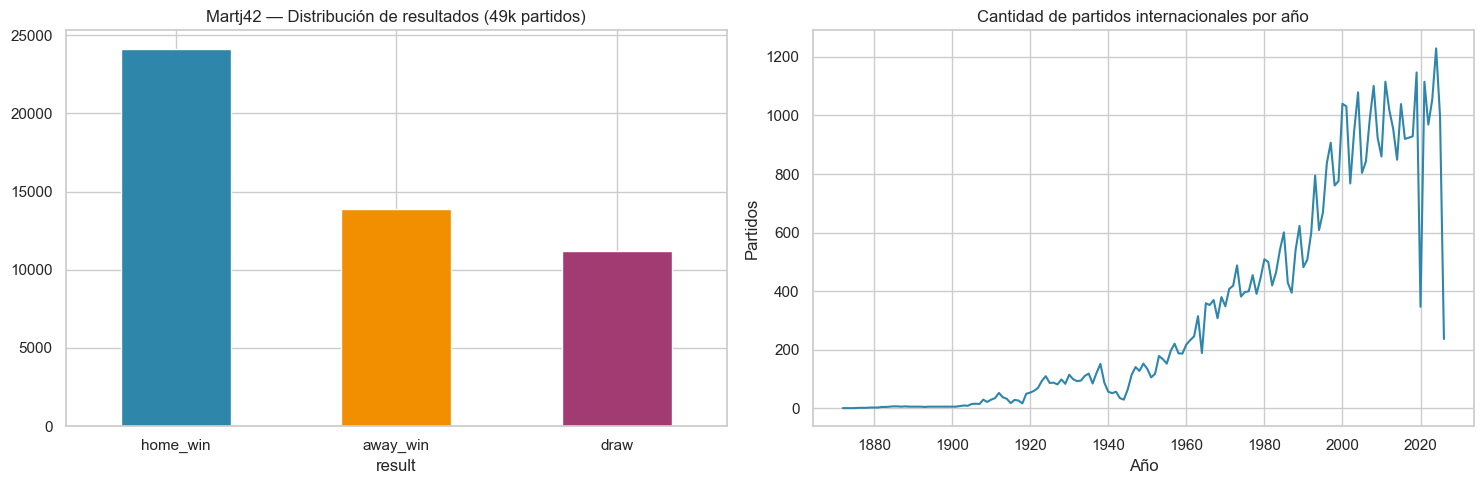

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ir_results.plot(kind='bar', ax=axes[0], color=['#2E86AB', '#F18F01', '#A23B72'])
axes[0].set_title('Martj42 — Distribución de resultados (49k partidos)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

ir['year'] = ir['date'].dt.year
ir.groupby('year').size().plot(ax=axes[1], color='#2E86AB')
axes[1].set_title('Cantidad de partidos internacionales por año')
axes[1].set_xlabel('Año'); axes[1].set_ylabel('Partidos')
plt.tight_layout(); plt.show()


Top 15 tipos de torneo:
tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Name: count, dtype: int64


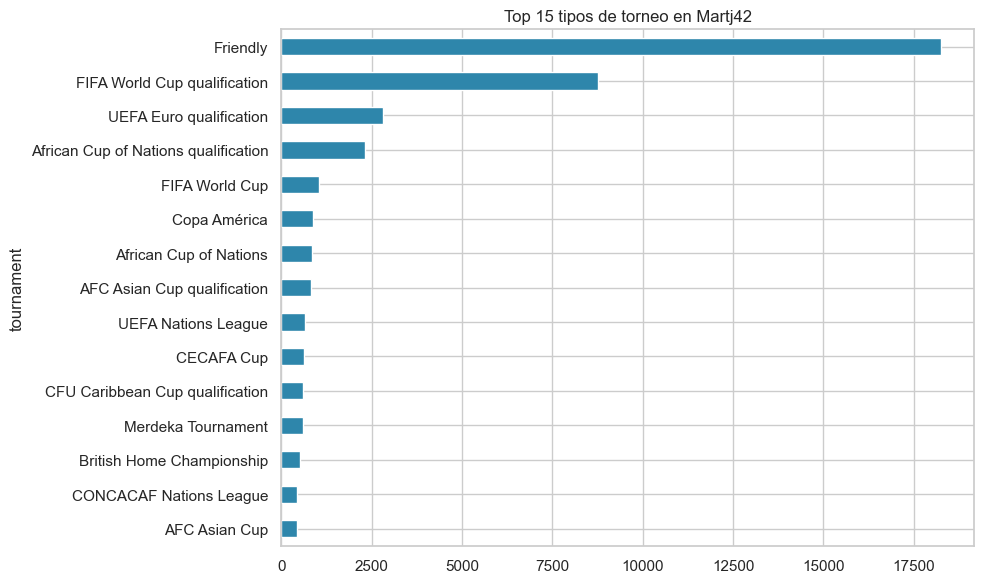

In [19]:
# Tipos de torneo más representados
tournament_counts = ir['tournament'].value_counts().head(15)
print('Top 15 tipos de torneo:')
print(tournament_counts)

fig, ax = plt.subplots(figsize=(10, 6))
tournament_counts.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 tipos de torneo en Martj42')
ax.invert_yaxis()
plt.tight_layout(); plt.show()


In [20]:
# Volumen de datos recientes (últimos 4 años) por selección
recent = ir[ir['date'] >= '2022-01-01']
print(f'Partidos desde 2022: {len(recent):,}')

all_teams = pd.concat([recent['home_team'], recent['away_team']])
team_match_counts = all_teams.value_counts()
print(f'Selecciones con datos recientes: {len(team_match_counts)}')
print(f'\nTop 20 con más partidos en 2022-2026:')
print(team_match_counts.head(20))


Partidos desde 2022: 4,486
Selecciones con datos recientes: 258

Top 20 con más partidos en 2022-2026:
Mexico           77
Saudi Arabia     74
Morocco          71
United States    71
Panama           70
Senegal          66
Algeria          64
Tunisia          64
Jamaica          64
Thailand         63
Egypt            63
South Korea      62
Qatar            62
Jordan           61
Bahrain          60
Costa Rica       60
Oman             60
Guatemala        60
South Africa     60
Burkina Faso     59
Name: count, dtype: int64


Distribución de resultados por sede:
          neutral  no_neutral (con localía)
result                                     
home_win    0.441                     0.507
away_win    0.334                     0.264
draw        0.224                     0.229


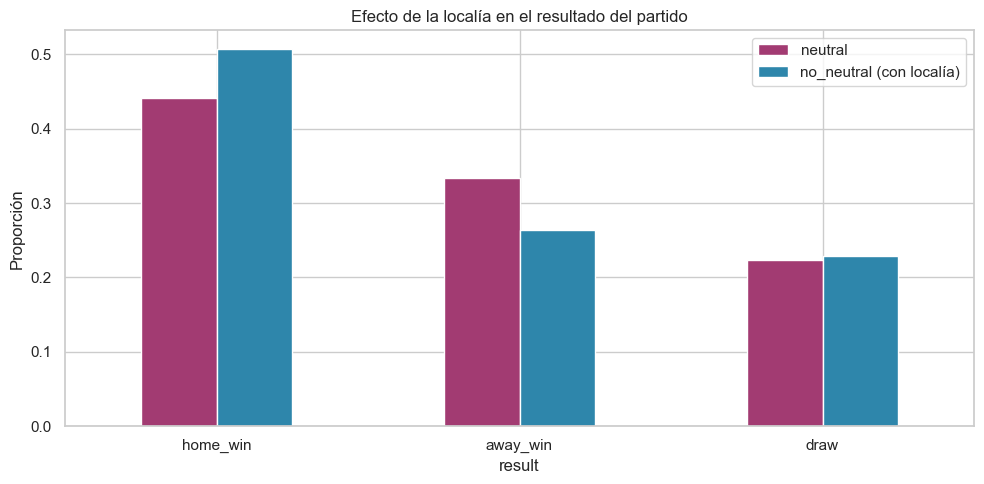

In [21]:
# Efecto de la localía: sede neutral vs no neutral
home_win_neutral = ir[ir['neutral']]['result'].value_counts(normalize=True).round(3)
home_win_local = ir[~ir['neutral']]['result'].value_counts(normalize=True).round(3)

comparison = pd.DataFrame({
    'neutral': home_win_neutral,
    'no_neutral (con localía)': home_win_local,
}).fillna(0)
print('Distribución de resultados por sede:')
print(comparison)

comparison.plot(kind='bar', figsize=(10,5), color=['#A23B72', '#2E86AB'])
plt.title('Efecto de la localía en el resultado del partido')
plt.ylabel('Proporción'); plt.xticks(rotation=0); plt.legend()
plt.tight_layout(); plt.show()


## 9. Die9origephit — FIFA World Cup 2022

64 partidos × 88 columnas con stats avanzadas. **Llena las brechas de Fjelstul**: posesión, intentos a puerta, corners, faltas, offsides, pases, crosses.

Es un dataset chico (solo el Mundial 2022) pero rico en features. Lo usaremos para:
1. Entrenar los modelos de regresión de la capa premium (corners, posesión, faltas)
2. Establecer baselines/priors para el Mundial 2026


In [22]:
from src.data import load_wc2022_matches

wc = load_wc2022_matches()
print('Shape:', wc.shape)
print('\nColumnas (88):')
for i, c in enumerate(wc.columns):
    print(f'  {i:3d}. {c}')


Shape: (64, 88)

Columnas (88):
    0. team1
    1. team2
    2. possession_team1
    3. possession_team2
    4. possession_in_contest
    5. number_of_goals_team1
    6. number_of_goals_team2
    7. date
    8. hour
    9. category
   10. total_attempts_team1
   11. total_attempts_team2
   12. conceded_team1
   13. conceded_team2
   14. goal_inside_the_penalty_area_team1
   15. goal_inside_the_penalty_area_team2
   16. goal_outside_the_penalty_area_team1
   17. goal_outside_the_penalty_area_team2
   18. assists_team1
   19. assists_team2
   20. on_target_attempts_team1
   21. on_target_attempts_team2
   22. off_target_attempts_team1
   23. off_target_attempts_team2
   24. attempts_inside_the_penalty_area_team1
   25. attempts_inside_the_penalty_area_team2
   26. attempts_outside_the_penalty_area_team1
   27. attempts_outside_the_penalty_area_team2
   28. left_channel_team1
   29. left_channel_team2
   30. left_inside_channel_team1
   31. left_inside_channel_team2
   32. central_channe

In [23]:
# Features clave para la capa premium
premium_features = ['team1', 'team2',
    'possession_team1', 'possession_team2',
    'total_attempts_team1', 'total_attempts_team2',
    'on_target_attempts_team1', 'on_target_attempts_team2',
    'corners_team1', 'corners_team2',
    'fouls_against_team1', 'fouls_against_team2',
    'yellow_cards_team1', 'yellow_cards_team2',
    'red_cards_team1', 'red_cards_team2',
    'offsides_team1', 'offsides_team2',
]
wc[premium_features].head()


,team1,team2,possession_team1,possession_team2,total_attempts_team1,total_attempts_team2,on_target_attempts_team1,on_target_attempts_team2,corners_team1,corners_team2,fouls_against_team1,fouls_against_team2,yellow_cards_team1,yellow_cards_team2,red_cards_team1,red_cards_team2,offsides_team1,offsides_team2
0,QATAR,ECUADOR,42.0,50.0,5,6,0,3,1,3,15,15,4,2,0,0,3,4
1,ENGLAND,IRAN,72.0,19.0,13,8,7,3,8,0,9,14,0,2,0,0,2,2
2,SENEGAL,NETHERLANDS,44.0,45.0,14,9,3,3,6,7,13,13,2,1,0,0,2,1
3,UNITED STATES,WALES,51.0,39.0,6,7,1,3,5,3,15,10,4,2,0,0,1,1
4,ARGENTINA,SAUDI ARABIA,64.0,24.0,14,3,6,2,9,2,7,21,0,6,0,0,10,1


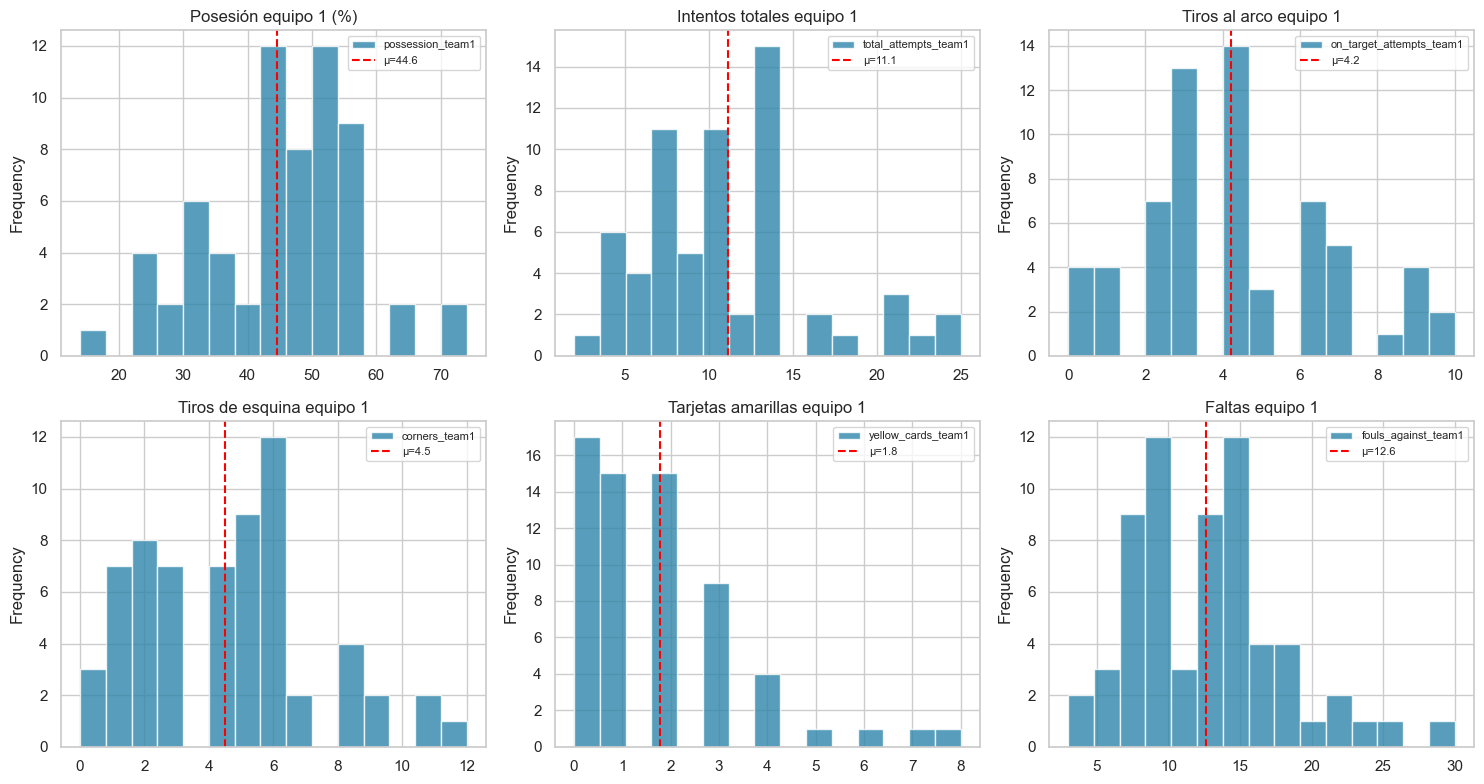

In [24]:
# Distribuciones de variables premium
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (col, title) in zip(axes.flat, [
    ('possession_team1', 'Posesión equipo 1 (%)'),
    ('total_attempts_team1', 'Intentos totales equipo 1'),
    ('on_target_attempts_team1', 'Tiros al arco equipo 1'),
    ('corners_team1', 'Tiros de esquina equipo 1'),
    ('yellow_cards_team1', 'Tarjetas amarillas equipo 1'),
    ('fouls_against_team1', 'Faltas equipo 1'),
]):
    wc[col].plot(kind='hist', ax=ax, bins=15, color='#2E86AB', alpha=0.8)
    ax.set_title(title); ax.set_xlabel('')
    ax.axvline(wc[col].mean(), color='red', linestyle='--', label=f'μ={wc[col].mean():.1f}')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


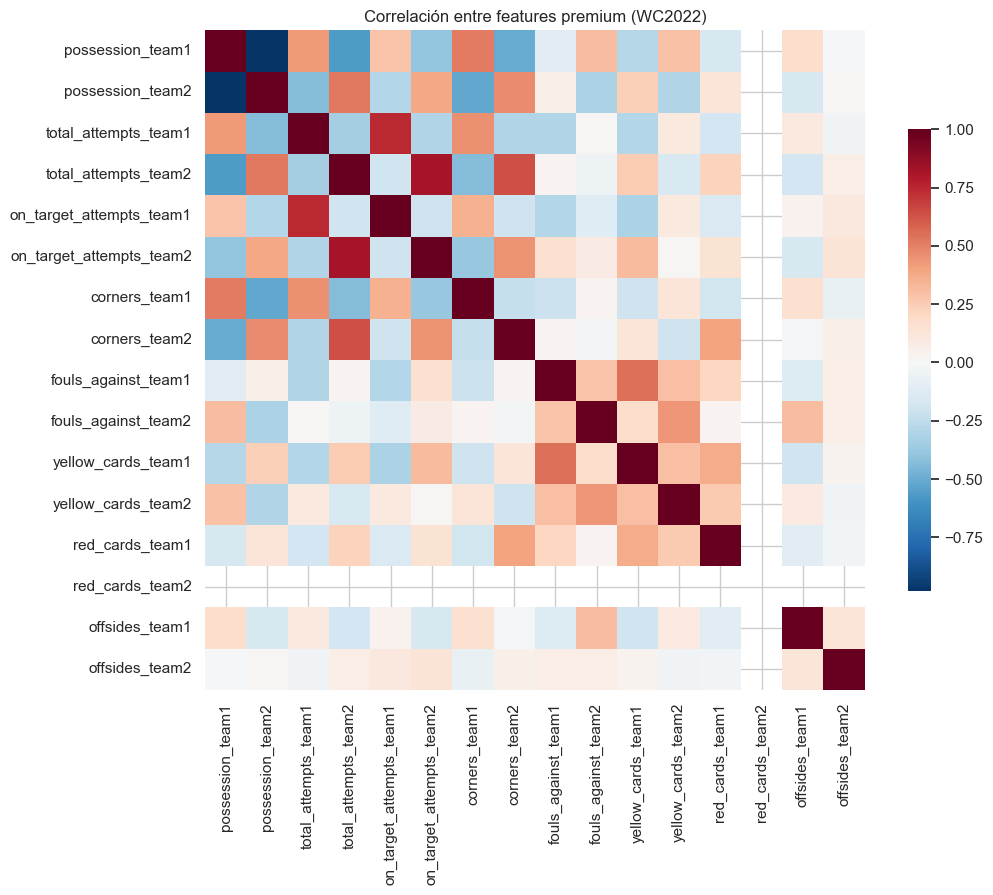


Correlaciones más fuertes:
possession_team1      possession_team2           -0.980
total_attempts_team2  on_target_attempts_team2    0.822
total_attempts_team1  on_target_attempts_team1    0.751
total_attempts_team2  corners_team2               0.639
possession_team1      total_attempts_team2       -0.565
fouls_against_team1   yellow_cards_team1          0.546
possession_team2      total_attempts_team2        0.523
                      corners_team1              -0.522
possession_team1      corners_team1               0.516
                      corners_team2              -0.505
dtype: float64


In [25]:
# Correlación entre features premium (informa feature selection)
premium_num = wc[premium_features].select_dtypes(include='number')
corr = premium_num.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, ax=ax, square=True, cbar_kws={'shrink':0.7})
ax.set_title('Correlación entre features premium (WC2022)')
plt.tight_layout(); plt.show()

corr_pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print('\nCorrelaciones más fuertes:')
print(corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index).head(10).round(3))


In [26]:
# Agregados por partido (targets potenciales de regresión)
wc['total_yellow'] = wc['yellow_cards_team1'] + wc['yellow_cards_team2']
wc['total_red'] = wc['red_cards_team1'] + wc['red_cards_team2']
wc['total_corners'] = wc['corners_team1'] + wc['corners_team2']
wc['total_fouls'] = wc['fouls_against_team1'] + wc['fouls_against_team2']

print('Estadísticas por partido (WC2022):')
print(wc[['total_yellow', 'total_red', 'total_corners', 'total_fouls']].describe().round(2))


Estadísticas por partido (WC2022):
       total_yellow  total_red  total_corners  total_fouls
count         64.00      64.00          64.00        64.00
mean           3.53       0.06           8.94        25.00
std            2.62       0.24           3.45         7.29
min            0.00       0.00           2.00        12.00
25%            2.00       0.00           7.00        20.00
50%            3.00       0.00           9.00        24.00
75%            5.00       0.00          11.00        28.25
max           16.00       1.00          20.00        48.00


## 10. Hugomathien — European Soccer Database

25.979 partidos de ligas europeas (clubes, no selecciones) entre 2008 y 2016. **No es directamente útil para predecir selecciones nacionales**, pero la usaremos como:

1. **Ratings de jugadores FIFA**: cruzar `Player_Attributes.overall_rating` con `squads.csv` de Fjelstul para estimar la calidad de cada selección.
2. **Entrenamiento auxiliar de modelos de regresión** (corners/posesión) con más volumen — útil si los 64 partidos de WC2022 son pocos.

Es opcional / secundario. Esta sección es ligera.


In [27]:
from src.data import query_european_soccer

matches_per_league = query_european_soccer('''
    SELECT l.name AS league, COUNT(*) AS matches
    FROM Match m JOIN League l ON l.id = m.league_id
    GROUP BY l.name ORDER BY matches DESC
''')
matches_per_league


,league,matches
0,Spain LIGA BBVA,3040
1,France Ligue 1,3040
2,England Premier League,3040
3,Italy Serie A,3017
4,Netherlands Eredivisie,2448
5,Germany 1. Bundesliga,2448
6,Portugal Liga ZON Sagres,2052
7,Poland Ekstraklasa,1920
8,Scotland Premier League,1824
9,Belgium Jupiler League,1728


In [28]:
# Ratings FIFA de jugadores (útil para feature engineering)
ratings = query_european_soccer('''
    SELECT overall_rating, potential, finishing, dribbling, ball_control, short_passing
    FROM Player_Attributes
    WHERE overall_rating IS NOT NULL
''')
print(f'Filas de ratings: {len(ratings):,}')
print(ratings.describe().round(1))


Filas de ratings: 183,142
       overall_rating  potential  finishing  dribbling  ball_control  \
count        183142.0   183142.0   183142.0   183142.0      183142.0   
mean             68.6       73.5       49.9       59.2          63.4   
std               7.0        6.6       19.0       17.7          15.2   
min              33.0       39.0        1.0        1.0           5.0   
25%              64.0       69.0       34.0       52.0          58.0   
50%              69.0       74.0       53.0       64.0          67.0   
75%              73.0       78.0       65.0       72.0          73.0   
max              94.0       97.0       97.0       97.0          97.0   

       short_passing  
count       183142.0  
mean            62.4  
std             14.2  
min              3.0  
25%             57.0  
50%             65.0  
75%             72.0  
max             97.0  


## 11. Estrategia de integración de datasets

Con los 4 datasets en mano, así queda la estrategia para alimentar cada modelo:

| Modelo | Fuente principal | Volumen | Notas |
|---|---|---|---|
| **Clasificación W/D/L** (capa free) | Martj42 `results.csv` | ~49k partidos | Filtrar a 1990+ para representatividad moderna |
| **Goles 1T/2T** | Fjelstul `goals` + Martj42 `goalscorers` (con minuto) | ~2.500 + ~47.000 | Cruzar para enriquecer |
| **Tarjetas (amarillas, rojas)** | Fjelstul `bookings` + WC2022 | ~2.500 + 64 | Modelos separados; rojas como clasificación binaria |
| **Corners** | WC2022 | 64 | Pocos datos — considerar Poisson Regression |
| **Posesión** | WC2022 | 64 | Idem; enriquecer con ratings FIFA promedios del squad |
| **Faltas / Offsides / Tiros** | WC2022 | 64 | Idem |
| **Over/Under 2.5** | Derivado de Martj42 | ~49k | Target binario sobre goles totales |
| **Clustering equipos** | Agregados de WC2022 + Martj42 | mixto | K-Means sobre features promediados por selección |

**Reto principal**: las features ricas (corners, posesión, faltas) solo existen para 64 partidos de WC2022. Esto significa que los modelos de regresión de esas variables tendrán **alta varianza**. Estrategias:

1. **Feature engineering por equipo**: usar el promedio histórico de cada selección desde Martj42 (goles, victorias, etc.) como proxies indirectos.
2. **Ratings agregados FIFA**: para cada selección, usar el promedio de `overall_rating` de sus jugadores convocados.
3. **Regularización fuerte** en los modelos premium (ridge, alta `min_samples_leaf` en RF).
4. Si las métricas son malas (R² < 0.3), considerar mostrar solo el **promedio histórico** de la selección en la UI premium, dejando claro que es una estimación a priori.

**Decisión a tomar**: ¿priorizamos partidos de Mundiales (subset de Martj42 `tournament == 'FIFA World Cup'`) o entrenamos con todos los partidos internacionales? Lo discutiremos antes del notebook de feature engineering.


## Próximos pasos

1. **Notebook `02_feature_engineering.ipynb`**: construir features por equipo (ventana móvil de últimos N partidos, diferencial de goles histórico, % victorias en H2H, etc.) — listas para alimentar el clasificador.
2. **Notebook `03_classification_model.ipynb`**: entrenar Random Forest, XGBoost y Regresión Logística para W/D/L; comparar contra baseline.
3. **Notebook `04_regression_models.ipynb`**: una vez tengamos los datasets externos, entrenar los modelos de regresión (goles, tarjetas, corners, posesión).
4. **Notebook `05_clustering.ipynb`**: K-Means para clasificar selecciones por estilo de juego.

Cuando todos los modelos estén entrenados y persistidos en `ml/trained_models/`, comenzamos con el backend FastAPI.